In [9]:
!pip install deap

In [10]:
import random
from deap import base, creator, tools, algorithms

# Define bounds for each variable as (min, max)
# [num_neurons, lr, batch_sz, act_func_i]
LOW =  [4,  0.001,  4, 0]   # Minimum bounds for variables
HIGH = [64,   1.5, 10, 1]   # Maximum bounds for variables
N_VAR = len(LOW)

# Define the optimization problem as minimization
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# Define the toolbox
toolbox = base.Toolbox()

# Variable 0: Continuous variable for num_neurons
toolbox.register("attr_float1", random.uniform, LOW[0], HIGH[0])

# Variable 1: Continuous variable for lr
toolbox.register("attr_float2", random.uniform, LOW[1], HIGH[1])

# Variable 2: Continuous variable for batch size
toolbox.register("attr_float3", random.uniform, LOW[2], HIGH[2])

# Variable 3: Discrete variable for act_func index
toolbox.register("attr_int", random.choice, [LOW[3], HIGH[3]]) # 0: relu, 1: sigmoid

# Combine variables into an individual
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_float1, toolbox.attr_float2, toolbox.attr_float3, toolbox.attr_int), n=1)

# Define the population
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [11]:
from keras.models import Sequential, save_model, load_model
from keras.layers import Dense, Activation, Input
from keras import optimizers, callbacks
import numpy as np

# Use (n, 1) shape instead of (n,), since (n, 1) is general input format for Keras DNN models
X = np.linspace(0, 1, 30).reshape(-1, 1) # -1 simply means that it is an unknown dimension and
y = -X*X                                 # we want numpy to figure it out.
Xt = np.linspace(0, 1, 7).reshape(-1, 1)
yt = -Xt * Xt

# num_neurons, lr, bsize, act_func
def eval_function(param):
  global m # to plot
  m = Sequential()
  m.add(Input(shape=(1,)))
  if round(param[3]) == 0:
      m.add(Dense(round(param[0]), activation='relu'))
  elif round(param[3]) == 1:
      m.add(Dense(round(param[0]), activation='sigmoid'))
  m.add(Dense(1))

  m.compile(optimizer=optimizers.SGD(learning_rate=param[1]), loss='mse')
  cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True),
  ]
  m.fit(X, y, epochs=300, batch_size=int(param[2]), verbose = 0,
    # validation_split=0.2, callbacks=cb_list)
    # To-do: When you use the validation_split parameter in the Keras fit() method,
    # the validation data is not selected at random by default.
    # Instead, Keras takes the last samples of your provided data based on the specified fraction.
    validation_data=(Xt, yt), callbacks=cb_list)
  loss = m.evaluate(Xt, yt, verbose=0)
  return (loss,)

In [12]:
toolbox.register("evaluate", eval_function)

# Define genetic operators
toolbox.register("mate", tools.cxBlend, alpha=0.5)  # Blend crossover for continuous variables
toolbox.register("mutate_cont", tools.mutGaussian, mu=0, sigma=2, indpb=0.5)  # Continuous mutation
toolbox.register("mutate_int", tools.mutUniformInt, low=LOW[3], up=HIGH[3], indpb=0.2)  # Discrete mutation
toolbox.register("select", tools.selTournament, tournsize=3)

# Custom mutation to handle both continuous and discrete parts
def custom_mutate(individual):
    # Mutate continuous variables (x0, x1 and x2)
    toolbox.mutate_cont(individual[:N_VAR-1])

    # Mutate discrete variable (x3)
    toolbox.mutate_int(individual[N_VAR-1:])
    return individual,

def check_bounds(individual):
    individual[0] = abs(np.clip(individual[0], LOW[0], HIGH[0])) # make sure positive ... ??
    individual[1] = abs(np.clip(individual[1], LOW[1], HIGH[1]))
    individual[2] = abs(np.clip(individual[2], LOW[2], HIGH[2]))
    individual[3] = abs(np.clip(individual[3], LOW[3], HIGH[3]))
    return individual, 0

toolbox.register("mutate", custom_mutate)
toolbox.decorate("mutate", tools.DeltaPenalty(check_bounds, 0))  # Use check_bounds function

# Main algorithm
def main():
    random.seed(77)

    # Create a population
    population = toolbox.population(n=10)

    # Statistics to track
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", min)
    # Extract the fitness value from the tuple for calculating average
    stats.register("avg", lambda lst: sum(x[0] for x in lst) / len(lst))


    # Run the genetic algorithm
    population, logbook = algorithms.eaSimple(population, toolbox,
                                              cxpb=0.5, mutpb=0.3,
                                              ngen=5, stats=stats, verbose=True)
    return population, logbook

if __name__ == "__main__":
    final_population, log = main()

    # Display the best solution
    best_individual = tools.selBest(final_population, k=1)[0]
    print("Best Individual:", best_individual)
    print("Fitness:", best_individual.fitness.values)
    print(final_population)


gen	nevals	min                     	avg    
0  	10    	(0.0008598496788181365,)	47199.6
1  	8     	(0.00026794394943863153,)	333.767
2  	6     	(0.00026794394943863153,)	0.062855
3  	5     	(0.00026794394943863153,)	0.0132773
4  	7     	(0.00017666940402705222,)	0.000662676
5  	8     	(0.0001591657055541873,) 	0.000430829
Best Individual: [np.float64(55.092193950584594), np.float64(0.24666710832906164), np.float64(5.593606352463205), np.float64(0.0)]
Fitness: (0.0001591657055541873,)
[[np.float64(55.092193950584594), np.float64(0.24666710832906164), np.float64(5.593606352463205), np.float64(0.0)], [np.float64(55.092193950584594), np.float64(0.24666710832906164), np.float64(5.593606352463205), np.float64(0.0)], [55.092193950584594, 0.24666710832906164, 5.593606352463205, 0.0], [np.float64(55.092193950584594), np.float64(0.24666710832906164), np.float64(5.593606352463205), np.float64(0.0)], [np.float64(55.092193950584594), np.float64(0.24666710832906164), np.float64(5.593606352463205), n

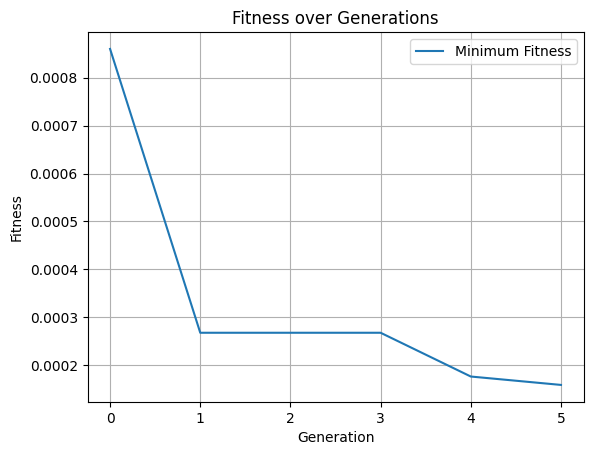

Model: "sequential_89"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_178 (Dense)               │ (None, 55)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_179 (Dense)               │ (None, 1)              │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168 (676.00 B)

 Trainable params: 166 (664.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

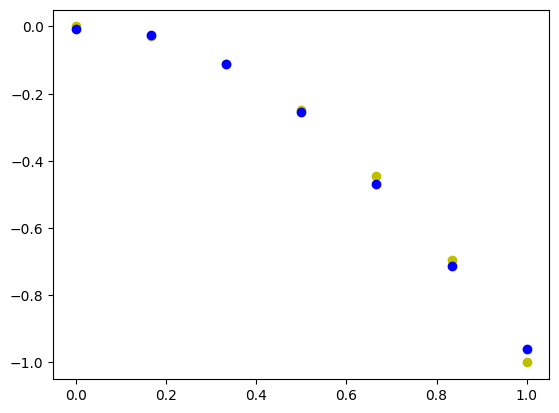

In [13]:
import matplotlib.pyplot as plt

# Assuming 'log' is the logbook from the previous code
gen = log.select("gen")
fit_mins = log.select("min")
fit_avgs = log.select("avg")

plt.plot(gen, fit_mins, label="Minimum Fitness")
#plt.plot(gen, fit_avgs, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Fitness over Generations")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# re-evauate the best individual in the latest population to get the model
eval_function(best_individual)
m.summary()
plt.plot(Xt, yt, 'yo') # yellow circle
plt.plot(Xt, m.predict(Xt, verbose=0), 'bo') # blue circles
plt.show()